In [1]:
import glob
import ast
import time
import numpy as np
import pandas as pd
from tqdm import tqdm 
import cv2
from PIL import Image
import re
import joblib
import matplotlib.pyplot as plt
import gc
import zipfile

from tqdm import tqdm
import shutil

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Verify GPU

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_type = torch.float32 if device.type == "cuda" else torch.float16
device, torch_type

(device(type='cuda'), torch.float32)

In [4]:
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3090
Memory: 25.43 GB


### Loading package

In [5]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [6]:
from py.utils import verifyDir,verifyFile

In [7]:
from py.config import Config

cfg = Config()
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA19/datasets/', '/media/felipe/DATA19/models/')

In [8]:
QSCORE_PATH=f"{cfg.DATA_PATH}pp2/Qscores/"
IMAGES_PATH = f"{cfg.DATA_PATH}pp2/images/"

### Loading data

In [9]:
%%time
data_df = pd.read_csv(f"{QSCORE_PATH}scores.csv", sep=";", low_memory=False)
data_df["image_path"] = IMAGES_PATH + data_df["image_path"]
data_df

CPU times: user 156 ms, sys: 31 ms, total: 187 ms
Wall time: 186 ms


,image_id,lat,long,city,country,continent,safety,beautiful,wealthy,lively,boring,depressing,image_path
0,50e5f7d4d7c3df413b00056a,22.310524,114.170637,Hong Kong,China,Asia,4.135536,1.574074,2.962963,4.199346,5.000000,0.000000,/media/felipe/DATA19/datasets/pp2/images/Hong ...
1,50e5f7d4d7c3df413b00056b,22.274799,114.192828,Hong Kong,China,Asia,3.560981,2.229437,5.277778,5.662393,7.777778,3.333333,/media/felipe/DATA19/datasets/pp2/images/Hong ...
2,50e5f7d4d7c3df413b00056c,22.291117,114.147373,Hong Kong,China,Asia,4.514946,3.333333,3.333333,4.746693,3.611111,0.000000,/media/felipe/DATA19/datasets/pp2/images/Hong ...
3,50e5f7d4d7c3df413b00056d,22.314273,114.177176,Hong Kong,China,Asia,4.852448,3.333333,5.083333,3.333333,8.333333,3.327381,/media/felipe/DATA19/datasets/pp2/images/Hong ...
4,50e5f7d4d7c3df413b00056e,22.332412,114.204790,Hong Kong,China,Asia,4.975207,2.129630,3.680556,4.343857,2.500000,4.444444,/media/felipe/DATA19/datasets/pp2/images/Hong ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
108433,5185d533fdc9f03fd500148d,45.635489,-73.514755,Montreal,Canada,North America,6.111111,5.833333,2.333333,3.495058,3.333333,9.166667,/media/felipe/DATA19/datasets/pp2/images/Montr...
108434,5185d533fdc9f03fd500148e,45.581265,-73.511511,Montreal,Canada,North America,4.797811,3.251984,2.777778,2.148291,7.222222,7.777778,/media/felipe/DATA19/datasets/pp2/images/Montr...
108435,5185d534fdc9f03fd500148f,45.591299,-73.520681,Montreal,Canada,North America,5.006830,6.888889,7.777778,6.176471,5.833333,2.611111,/media/felipe/DATA19/datasets/pp2/images/Montr...
108436,5185d534fdc9f03fd5001490,45.470656,-73.631901,Montreal,Canada,North America,4.551622,3.333333,5.000000,5.008547,3.611111,2.962963,/media/felipe/DATA19/datasets/pp2/images/Montr...


##### Convert classes and colors file

In [10]:
from py.datasets import UrbanPhysicalDisorder

uss = UrbanPhysicalDisorder(data_path=cfg.DATA_PATH)
uss.generate_dataset(dataset=f"{cfg.SEG_DATASET}")

In [11]:
classes_df = uss.get_urban_street_categories(by_groups=False)
classes_df

,class_id,main_class,class_name,RGB_color,hex_color,isthing,group_name
0,1,wall,wall,"(120, 120, 120)",#787878,0,construction
1,2,building,building;edifice,"(180, 120, 120)",#B47878,0,construction
2,3,sky,sky,"(6, 230, 230)",#06E6E6,0,sky
3,4,floor,floor;flooring,"(80, 50, 50)",#503232,0,floor
4,5,tree,tree,"(4, 200, 3)",#04C803,0,vegetation
...,...,...,...,...,...,...,...
145,146,shower,shower,"(0, 133, 255)",#0085FF,0,indoor_object
146,147,radiator,radiator,"(255, 214, 0)",#FFD600,1,terrain_vehicle_related
147,148,glass,glass;drinking;glass,"(25, 194, 194)",#19C2C2,1,miscellaneous
148,149,clock,clock,"(102, 255, 0)",#66FF00,1,miscellaneous


### Scene Parser

Here are some key aspects of scene parsing:

* Object Detection and Classification: Scene parsers identify objects (e.g., cars, people, trees) in an image or video and classify them into predefined categories.

* Semantic Segmentation: Scene parsing may also involve pixel-level classification, where each pixel in the image is assigned to a class (e.g., sky, road, building).

* Instance Segmentation: This step not only assigns pixels to classes but also differentiates between multiple instances of the same object type (e.g., separating two people in the scene).

* Contextual Understanding: Beyond identifying objects, a scene parser may analyze the spatial relationships between objects and infer interactions, like people sitting on chairs or cars parked on the road.

#### Stuff vs. Thing in ADE20K
- Stuff `(isthing = 0)`: Background elements like sky, road, water, wall, tree, grass.  
- Thing `(isthing = 1)`: Countable objects like bed, chair, person, car, bicycle.


### Zero-shot Segmenter

In [12]:
from py.models.segmentation import ImageSegmenter

ImageSegmenter().model_zoo()

Model zoo ADE20K and CityScapes: ['OneFormer_Swin_Large', 'OneFormer_Swin_Tiny', 'OneFormer_Dinat_Large', 'Mask2Former_Swin_Large', 'Mask2Former_Swin_Base', 'Mask2Former_Swin_Small', 'Mask2Former_Swin_Tiny', 'SegFormer_B0', 'SegFormer_B1', 'SegFormer_B2', 'SegFormer_B3', 'SegFormer_B4', 'SegFormer_B5'] 

Model Zoo only ADE20K-pytorch: PSP_ResNet50_Dilated 

Model Zoo only ADE20K-keras: DeepLabV3_Exception65 



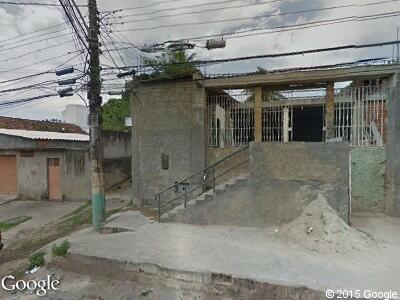

In [13]:
# image_sample = Image.open(data_df["image_path"][1000]).convert("RGB")
image_sample = Image.open(data_df[data_df["image_id"]=="50f5ec44fdc9f065f0008911"]["image_path"].values[0]).convert("RGB")
# image_sample = Image.open(data_df[data_df["image_id"]=="50f5ec42fdc9f065f00088e3"]["image_path"].values[0]).convert("RGB")
# image_sample = Image.open(data_df[data_df["image_id"]=="50f5ea61fdc9f065f0007b20"]["image_path"].values[0]).convert("RGB")
# image_sample = Image.open(data_df[data_df["image_id"]=="50f5ec41fdc9f065f00088c1"]["image_path"].values[0]).convert("RGB")
# image_sample = Image.open(data_df[data_df["image_id"]=="50f5ec33fdc9f065f00087c3"]["image_path"].values[0]).convert("RGB")
image_sample

##### PSPNet

Loading pretrained model: shuangzhao/pspnet-resnet50-ade-dilated
Loading weights for net_encoder
Loading weights for net_decoder
Model arch used: shuangzhao/pspnet-resnet50-ade-dilated 

Trainable parameters in the model:
   Total parameters: 51,579,116
   Trainable parameters: 51,579,116
   Trainable parameters percentage: 100.0000%


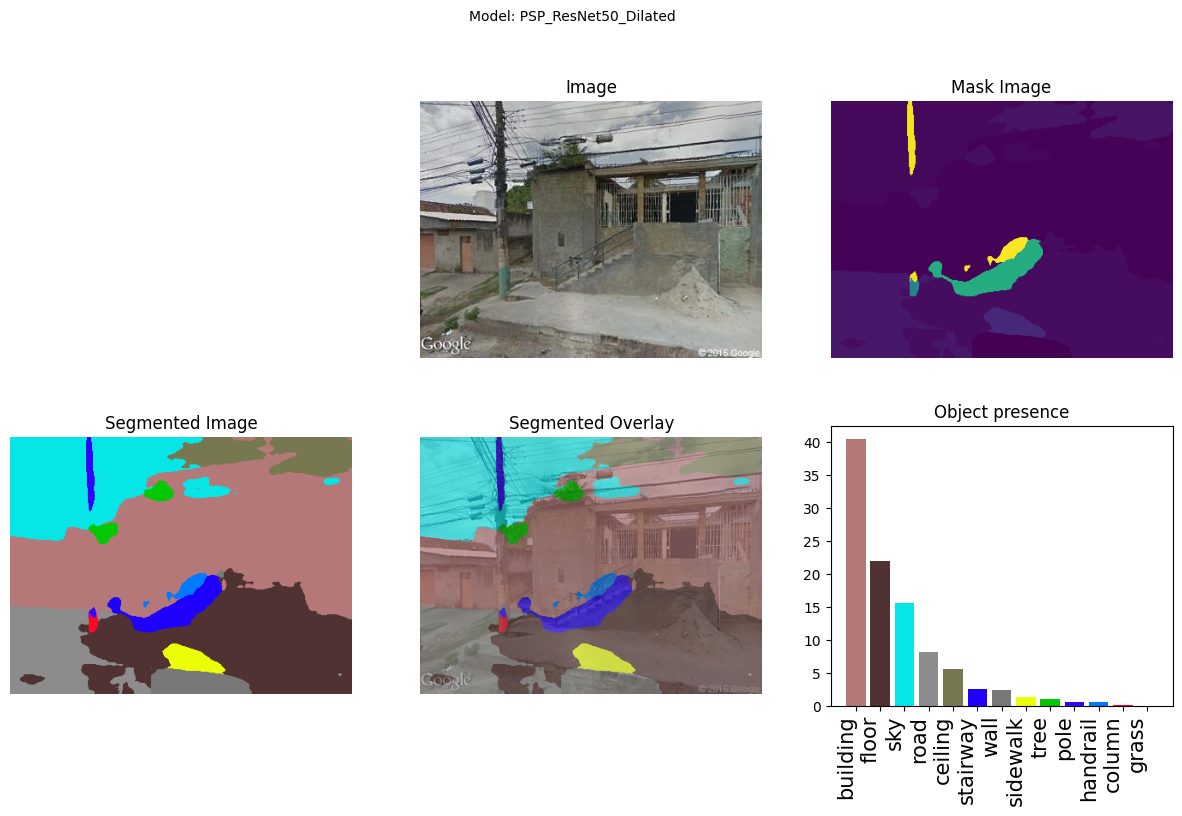

CPU times: user 1.46 s, sys: 312 ms, total: 1.77 s
Wall time: 1.02 s


In [14]:
%%time
ts = ImageSegmenter(model_name="PSP_ResNet50_Dilated", model_path=f"{cfg.MODEL_PATH}ade20k/", dataset=cfg.SEG_DATASET)
ts.to_device(device)
ts.eval()

ts.print_trainable_parameters()

ratio_df, masks, seg_img, seg_overlay_img = ts.zeroshot_segmentation(image_sample, classes_df=classes_df)

# Plot the original image and the segmented image side by side
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 2)
plt.imshow(image_sample)
plt.title('Image')
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(masks)
plt.title('Mask Image')
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(seg_img)
plt.title('Segmented Image')
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(seg_overlay_img)
plt.title('Segmented Overlay')
plt.axis("off")

plt.subplot(2, 3, 6)
plt.bar(ratio_df["main_class"], ratio_df["ratio"], color=ratio_df["hex_color"])
plt.title('Object presence')
plt.xticks(rotation=90, ha="right", fontsize=15)

plt.suptitle(f'Model: {ts.get_model_name()}', fontsize=10)
plt.show()

##### SegFormer

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Model arch used: nvidia/segformer-b5-finetuned-ade-640-640 

Trainable parameters in the model:
   Total parameters: 84,708,694
   Trainable parameters: 84,708,694
   Trainable parameters percentage: 100.0000%


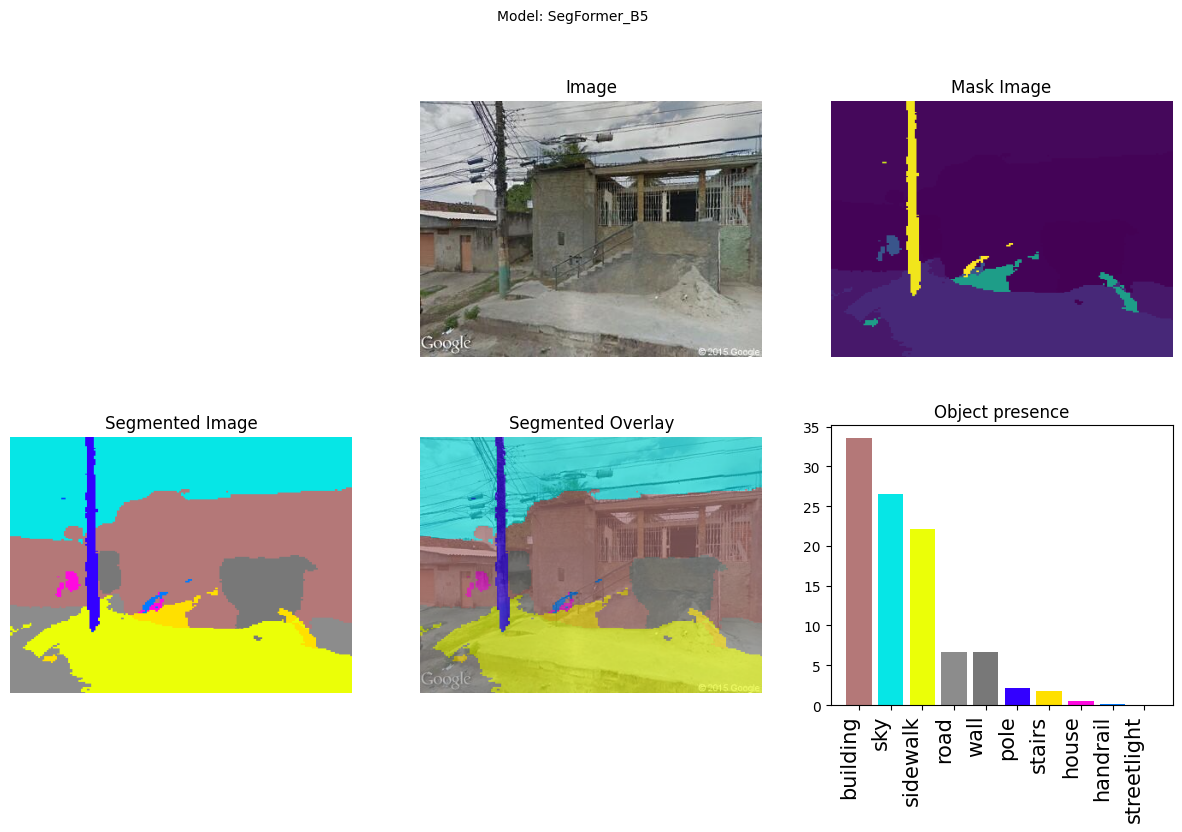

CPU times: user 952 ms, sys: 86.8 ms, total: 1.04 s
Wall time: 1.98 s


In [15]:
%%time
ts = ImageSegmenter(model_name="SegFormer_B5", dataset=cfg.SEG_DATASET)
ts.to_device(device)
ts.eval()

ts.print_trainable_parameters()

ratio_df, masks, seg_img, seg_overlay_img = ts.zeroshot_segmentation(image_sample, classes_df=classes_df)

# Plot the original image and the segmented image side by side
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 2)
plt.imshow(image_sample)
plt.title('Image')
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(masks)
plt.title('Mask Image')
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(seg_img)
plt.title('Segmented Image')
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(seg_overlay_img)
plt.title('Segmented Overlay')
plt.axis("off")

plt.subplot(2, 3, 6)
plt.bar(ratio_df["main_class"], ratio_df["ratio"], color=ratio_df["hex_color"])
plt.title('Object presence')
plt.xticks(rotation=90, ha="right", fontsize=15)

plt.suptitle(f'Model: {ts.get_model_name()}', fontsize=10)
plt.show()

##### Mask2Former

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Model arch used: facebook/mask2former-swin-large-ade-semantic 

Trainable parameters in the model:
   Total parameters: 215,488,779
   Trainable parameters: 215,488,779
   Trainable parameters percentage: 100.0000%


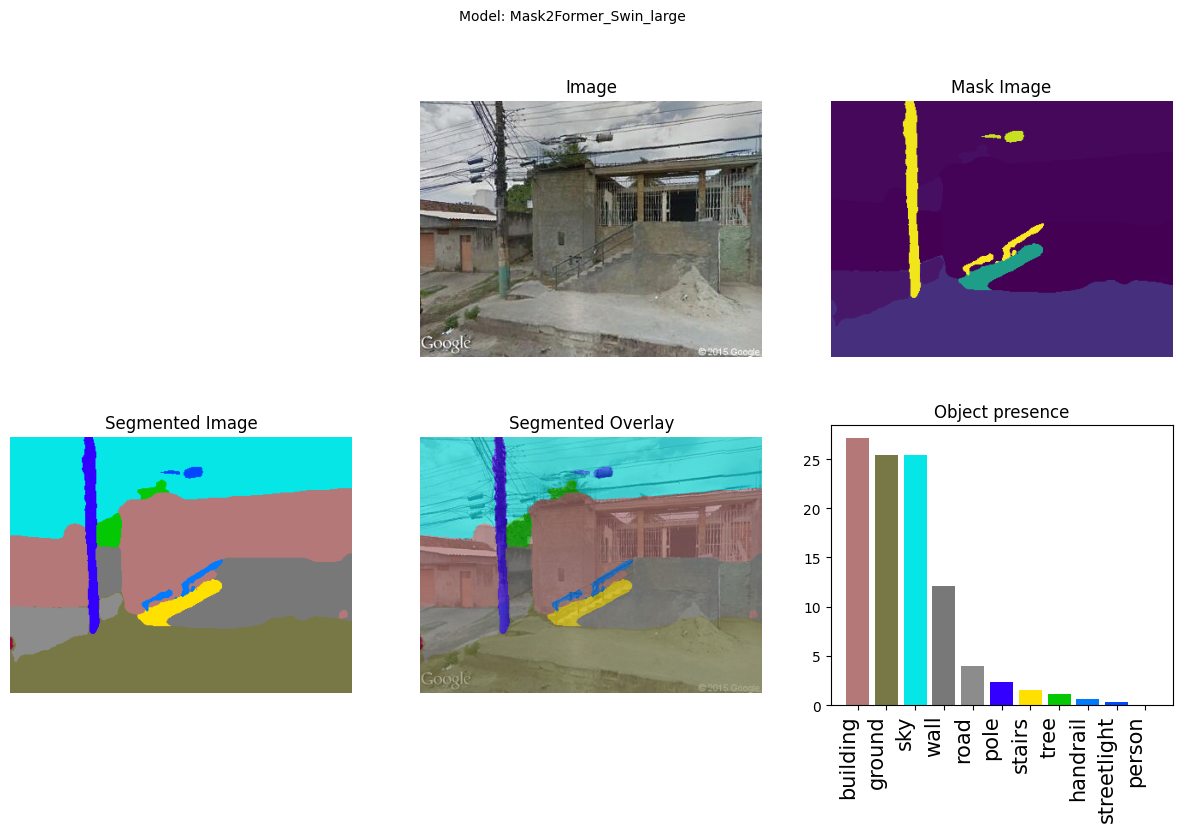

CPU times: user 1.18 s, sys: 208 ms, total: 1.39 s
Wall time: 1.48 s


In [16]:
%%time
ts = ImageSegmenter(model_name="Mask2Former_Swin_Large", dataset=cfg.SEG_DATASET)
ts.to_device(device)
ts.eval()

ts.print_trainable_parameters()

ratio_df, masks, seg_img, seg_overlay_img = ts.zeroshot_segmentation(image_sample, classes_df=classes_df)

# Plot the original image and the segmented image side by side
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 2)
plt.imshow(image_sample)
plt.title('Image')
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(masks)
plt.title('Mask Image')
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(seg_img)
plt.title('Segmented Image')
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(seg_overlay_img)
plt.title('Segmented Overlay')
plt.axis("off")

plt.subplot(2, 3, 6)
plt.bar(ratio_df["main_class"], ratio_df["ratio"], color=ratio_df["hex_color"])
plt.title('Object presence')
plt.xticks(rotation=90, ha="right", fontsize=15)

plt.suptitle(f'Model: {ts.get_model_name()}', fontsize=10)
plt.show()

##### OneFormer

Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

Model arch used: shi-labs/oneformer_ade20k_swin_large 

Trainable parameters in the model:
   Total parameters: 218,811,148
   Trainable parameters: 218,811,148
   Trainable parameters percentage: 100.0000%


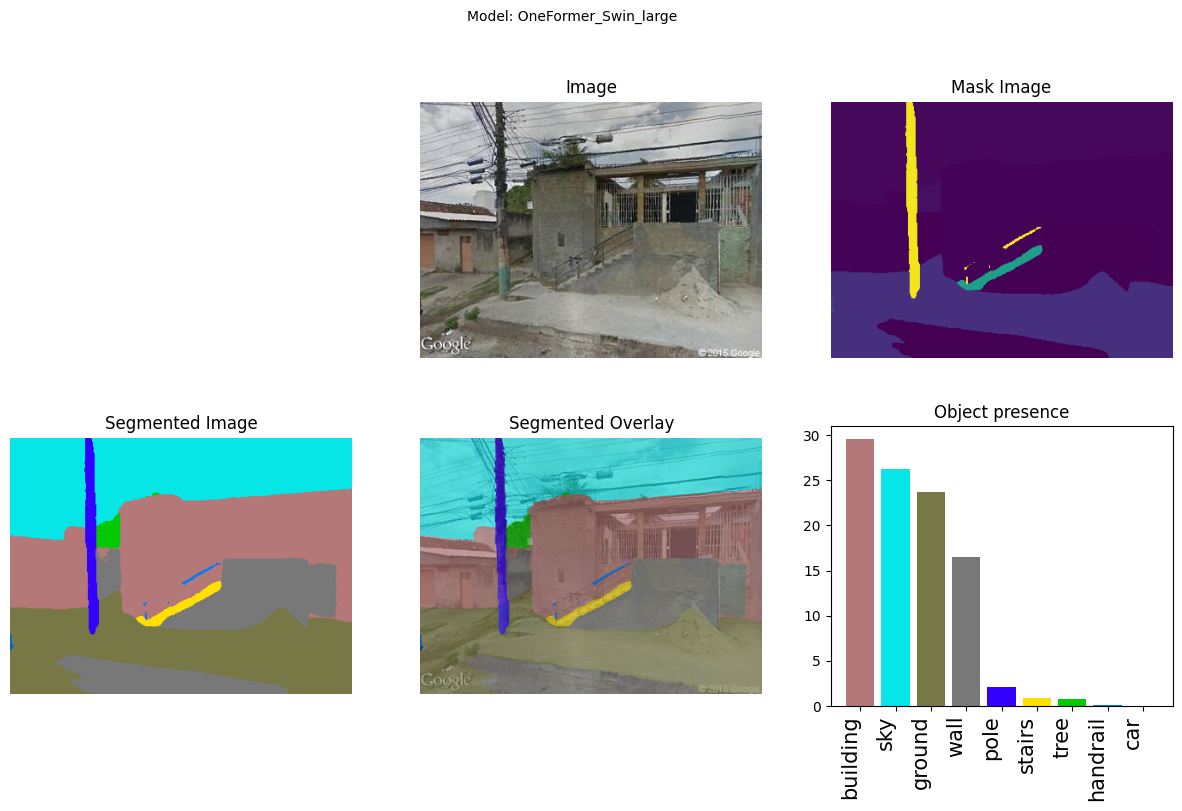

CPU times: user 1.41 s, sys: 97.3 ms, total: 1.51 s
Wall time: 3.83 s


In [17]:
%%time
ts = ImageSegmenter(model_name="OneFormer_Swin_Large", dataset=cfg.SEG_DATASET)
ts.to_device(device)
ts.eval()

ts.print_trainable_parameters()

ratio_df, masks, seg_img, seg_overlay_img = ts.zeroshot_segmentation(image_sample, classes_df=classes_df)

# Plot the original image and the segmented image side by side
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 2)
plt.imshow(image_sample)
plt.title('Image')
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(masks)
plt.title('Mask Image')
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(seg_img)
plt.title('Segmented Image')
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(seg_overlay_img)
plt.title('Segmented Overlay')
plt.axis("off")

plt.subplot(2, 3, 6)
plt.bar(ratio_df["main_class"], ratio_df["ratio"], color=ratio_df["hex_color"])
plt.title('Object presence')
plt.xticks(rotation=90, ha="right", fontsize=15)

plt.suptitle(f'Model: {ts.get_model_name()}', fontsize=10)
plt.show()